First make the dataset, </br>
Visualise them, </br>
Make dataloader, </br>
Split the dataset, </br>
Make model using nn.Module import, </br>
Make a training loop, </br>
Test and evaluate.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} for device.")

Using cuda for device.


In [476]:
# Dataset creation
class CustomDataset(Dataset):
    def __init__(self, n:int):
        super().__init__()
        self.x = torch.linspace(0, 4, n, dtype=torch.float32)
        self.y = self.x**2 + self.x + torch.randn(n)
    
    def __len__(self):
        return self.x.shape[0]
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [477]:
# Let the client decide the no. of data
dataset = CustomDataset(n=100)

In [478]:
dataset.x

tensor([0.0000, 0.0404, 0.0808, 0.1212, 0.1616, 0.2020, 0.2424, 0.2828, 0.3232,
        0.3636, 0.4040, 0.4444, 0.4848, 0.5253, 0.5657, 0.6061, 0.6465, 0.6869,
        0.7273, 0.7677, 0.8081, 0.8485, 0.8889, 0.9293, 0.9697, 1.0101, 1.0505,
        1.0909, 1.1313, 1.1717, 1.2121, 1.2525, 1.2929, 1.3333, 1.3737, 1.4141,
        1.4545, 1.4949, 1.5354, 1.5758, 1.6162, 1.6566, 1.6970, 1.7374, 1.7778,
        1.8182, 1.8586, 1.8990, 1.9394, 1.9798, 2.0202, 2.0606, 2.1010, 2.1414,
        2.1818, 2.2222, 2.2626, 2.3030, 2.3434, 2.3838, 2.4242, 2.4646, 2.5051,
        2.5455, 2.5859, 2.6263, 2.6667, 2.7071, 2.7475, 2.7879, 2.8283, 2.8687,
        2.9091, 2.9495, 2.9899, 3.0303, 3.0707, 3.1111, 3.1515, 3.1919, 3.2323,
        3.2727, 3.3131, 3.3535, 3.3939, 3.4343, 3.4747, 3.5152, 3.5556, 3.5960,
        3.6364, 3.6768, 3.7172, 3.7576, 3.7980, 3.8384, 3.8788, 3.9192, 3.9596,
        4.0000])

In [479]:
y_view = np.log10(dataset.y.detach().numpy())
i = 0

for y in y_view:
    print(f"Y: {y: > 0.3f}", end="  ")
    i += 1
    if i % 10 == 0:
        print()

Y:  0.274  Y:  nan  Y:  nan  Y: -1.322  Y: -0.390  Y:  0.419  Y:  nan  Y: -0.093  Y:  nan  Y:  0.108  
Y:  nan  Y: -0.010  Y:  0.048  Y:  nan  Y: -0.110  Y:  0.010  Y: -0.003  Y: -0.079  Y:  0.247  Y:  nan  
Y:  0.099  Y:  0.192  Y:  0.470  Y:  0.468  Y:  0.406  Y:  0.409  Y:  0.172  Y:  0.172  Y:  0.662  Y:  0.363  
Y:  0.320  Y:  0.418  Y:  0.614  Y:  0.415  Y:  0.336  Y:  0.568  Y:  0.584  Y:  0.137  Y:  0.599  Y:  0.553  
Y:  0.513  Y:  0.384  Y:  0.624  Y:  0.756  Y:  0.713  Y:  0.649  Y:  0.764  Y:  0.859  Y:  0.727  Y:  0.763  
Y:  0.762  Y:  0.713  Y:  0.902  Y:  0.680  Y:  0.803  Y:  0.785  Y:  0.842  Y:  0.831  Y:  0.788  Y:  0.956  
Y:  0.939  Y:  0.933  Y:  0.994  Y:  0.994  Y:  0.846  Y:  1.039  Y:  1.070  Y:  0.882  Y:  1.017  Y:  0.965  
Y:  1.056  Y:  1.023  Y:  1.048  Y:  1.035  Y:  1.004  Y:  1.047  Y:  1.113  Y:  1.115  Y:  1.113  Y:  1.078  
Y:  1.094  Y:  1.143  Y:  1.154  Y:  1.155  Y:  1.219  Y:  1.154  Y:  1.166  Y:  1.196  Y:  1.233  Y:  1.189  
Y:  1.242  Y:  

C:\Users\User\AppData\Local\Temp\ipykernel_24376\3797959354.py:1: RuntimeWarning: invalid value encountered in log10
  y_view = np.log10(dataset.y.detach().numpy())


In [480]:
x_view = np.log10(dataset.x.detach().numpy())
x = np.linspace(1, 100, 100)

C:\Users\User\AppData\Local\Temp\ipykernel_24376\3654641696.py:1: RuntimeWarning: divide by zero encountered in log10
  x_view = np.log10(dataset.x.detach().numpy())


<Figure size 1000x600 with 0 Axes>

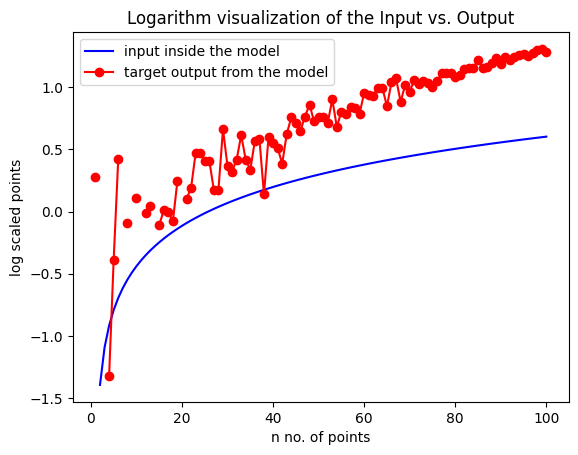

<Figure size 1000x600 with 0 Axes>

In [481]:
plt.plot(x, x_view, 'b', label="input inside the model")
plt.plot(x, y_view, 'ro-', label="target output from the model")
plt.title("Logarithm visualization of the Input vs. Output")
plt.xlabel("n no. of points")
plt.ylabel("log scaled points")
plt.legend()
plt.figure(figsize=(10, 6))


In [482]:
from torch.utils.data import random_split

generator1 = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [0.7, 0.3], generator1)    

In [483]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [484]:
x_feature, y_feature = next(iter(train_loader))
print("Feature shape for x: ", x_feature.shape)
print("Feature shape for y: ", y_feature.shape)

for images, coord in train_loader:
    print(f"Images shape are {images.shape}")
    print(f"Coord shape are {coord.shape}")

Feature shape for x:  torch.Size([2])
Feature shape for y:  torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape are torch.Size([2])
Coord shape are torch.Size([2])
Images shape a

In [485]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.weights = nn.Parameter(torch.empty(1, 1))
        self.bias = nn.Parameter(torch.ones(1))
        
        nn.init.xavier_uniform_(self.weights)
        
    def forward(self, x):
        
        return x @ self.weights.T + self.bias 
    
model = NeuralNetwork().to(device)

In [536]:
epochs = 250
alpha = 1e-5
total_loss = 0

In [487]:
for i, (X, y) in enumerate(train_loader):
    print(f"i:{i}, X:{X}, y:{y}")

i:0, X:tensor([4.0000, 1.4949]), y:tensor([19.2845,  1.3714])
i:1, X:tensor([1.8182, 3.3535]), y:tensor([ 4.4555, 14.2777])
i:2, X:tensor([0.7273, 2.9495]), y:tensor([ 1.7671, 10.8401])
i:3, X:tensor([2.8687, 2.9899]), y:tensor([10.5402, 10.1032])
i:4, X:tensor([0.7677, 3.3131]), y:tensor([-0.1868, 14.2599])
i:5, X:tensor([2.2626, 0.1616]), y:tensor([6.9450, 0.4077])
i:6, X:tensor([2.7071, 2.5051]), y:tensor([7.6230, 9.8664])
i:7, X:tensor([0.4444, 3.1515]), y:tensor([ 0.9763, 12.9820])
i:8, X:tensor([2.8283, 0.3636]), y:tensor([11.3686,  1.2822])
i:9, X:tensor([0.2020, 0.2424]), y:tensor([ 2.6270, -0.0970])
i:10, X:tensor([0.5253, 3.9192]), y:tensor([-0.3714, 19.9853])
i:11, X:tensor([2.5455, 0.6465]), y:tensor([9.8662, 0.9924])
i:12, X:tensor([1.7374, 1.8586]), y:tensor([5.7036, 5.8034])
i:13, X:tensor([2.0606, 3.7980]), y:tensor([ 5.1653, 18.5214])
i:14, X:tensor([3.9596, 1.3333]), y:tensor([20.2822,  2.5990])
i:15, X:tensor([2.6263, 0.8081]), y:tensor([10.9405,  1.2551])
i:16, X:te

In [488]:
list(model.parameters())

[Parameter containing:
 tensor([[0.1615]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([1.], device='cuda:0', requires_grad=True)]

In [489]:
optimizer = optim.SGD(params=model.parameters(), lr=alpha, weight_decay=0.01, momentum=0.8)

In [490]:
y_ = model(torch.tensor([1.]).to(device))
y_

tensor([1.1615], device='cuda:0', grad_fn=<AddBackward0>)

In [491]:
for epoch in range(epochs):
    for idx, data in enumerate(train_loader):
        X, y = data
        X = X.to(device)
        y = y.to(device)
        
        # Forward Pass
        y_pred = model(X.unsqueeze(1))
        
        ## loss calc
        loss = torch.mean((y[:, None] - y_pred)**2)
        
        total_loss += loss       
        
        print("loss", loss)
        
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        
        # Update Weights
        optimizer.step()
        
    print(f"loss: {total_loss/idx+1}, for epoch{epoch}/{epochs}")

loss tensor(5.3622, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(49.8160, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(45.2740, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(1.1941, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(96.5397, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(2.8302, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(55.2293, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(29.1750, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(5.4430, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(156.8498, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(142.4883, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(9.7125, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(7.3373, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(180.1430, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(3.0322, device='cuda:0', grad_fn=<MeanBackward0>)
loss tensor(2.8661, device='cuda:0', grad_fn=<MeanBackward0

### Data Visualization


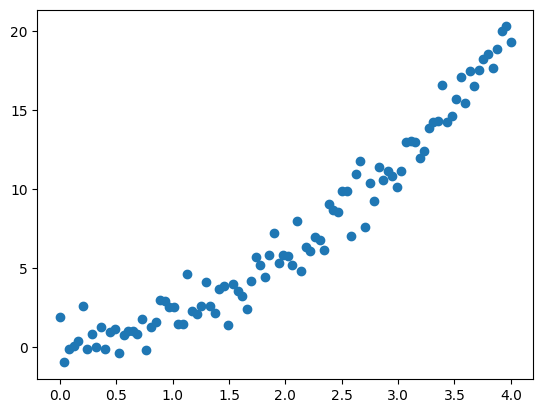

In [492]:
plt.scatter(dataset[:][0], dataset[:][1])

In [584]:
# Input Layer - 1 Neuron (1x3) hidden_dim
# Hidden 1 - hidden_dim Neurons  (3x3)  hidden_dim
# Hidden 2 - hidden_dim Neurons  (3x1)  1
# Output Layer - 1 Neuron 
class NaiveLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # Setting a=sqrt(5) in kaiming_uniform is the same as initializing with
        # uniform(-1/sqrt(in_features), 1/sqrt(in_features)). For details, see
        # https://github.com/pytorch/pytorch/issues/57109
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)
    def forward(self, x):
        
        return x @ self.weight + self.bias
    
    
class BetterNet(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Dropout(),
            nn.Linear(hidden_dim, 2*hidden_dim),
            nn.Tanh(),
            nn.Dropout(),
            nn.Linear(2*hidden_dim, 4*hidden_dim),
            nn.Tanh(),
            nn.Dropout(),
            nn.Linear(4*hidden_dim, 2*hidden_dim),
            nn.Tanh(),
            nn.Dropout(),
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(hidden_dim, 1),
            nn.ReLU()
        )    
        
    def forward(self, x):
        
        return self.net(x)

In [585]:
model_bet = BetterNet(hidden_dim=128).to(device)

In [586]:
optimizer_bet = optim.Adam(params=model_bet.parameters(), lr=4e-4)

In [587]:
model_bet(torch.tensor([[93.],[20.]]).to(device))

tensor([[0.1245],
        [0.2363]], device='cuda:0', grad_fn=<ReluBackward0>)

In [588]:
for epoch in range(epochs):
    total = 0
    for idx, data in enumerate(train_loader):
        X, y = data
        X = X.to(device)
        y = y.to(device)
        
        # forward pass
        y_pred = model_bet(X[:, None])
        
        ## loss calc
        loss_bet = F.mse_loss(y_pred.squeeze(), y)
        total += loss_bet
        
        # backward pass
        optimizer_bet.zero_grad()
        loss_bet.backward()
        
        # params update
        optimizer_bet.step()
        
    print(f"loss: {total/len(train_loader)} for epoch {epoch+1}/{epochs}")

loss: 85.48338317871094 for epoch 1/250
loss: 41.89152145385742 for epoch 2/250
loss: 25.506410598754883 for epoch 3/250
loss: 16.16951560974121 for epoch 4/250
loss: 9.579718589782715 for epoch 5/250
loss: 8.690356254577637 for epoch 6/250
loss: 11.271787643432617 for epoch 7/250
loss: 12.358019828796387 for epoch 8/250
loss: 8.46509075164795 for epoch 9/250
loss: 12.466346740722656 for epoch 10/250
loss: 10.960688591003418 for epoch 11/250
loss: 10.450760841369629 for epoch 12/250
loss: 13.275691986083984 for epoch 13/250
loss: 10.631488800048828 for epoch 14/250
loss: 8.687115669250488 for epoch 15/250
loss: 12.900174140930176 for epoch 16/250
loss: 12.929923057556152 for epoch 17/250
loss: 11.660357475280762 for epoch 18/250
loss: 10.413756370544434 for epoch 19/250
loss: 12.470190048217773 for epoch 20/250
loss: 8.562100410461426 for epoch 21/250
loss: 7.190635681152344 for epoch 22/250
loss: 12.65372371673584 for epoch 23/250
loss: 10.009913444519043 for epoch 24/250
loss: 8.2153

In [589]:
model_bet(torch.tensor([309.]).to(device))

tensor([17.7520], device='cuda:0', grad_fn=<ReluBackward0>)

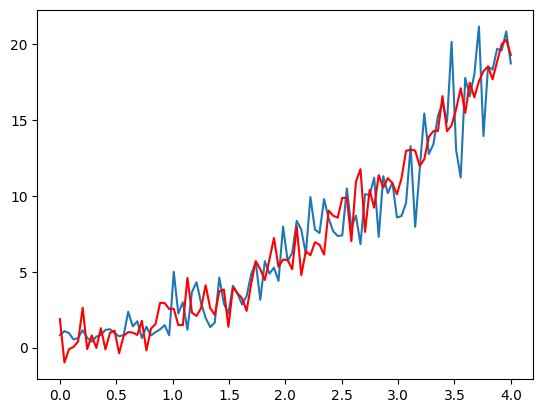

In [590]:
plt.plot(dataset[:][0], model_bet(dataset[:][0][:, None].cuda()).detach().cpu())
plt.plot(dataset[:][0], dataset[:][1], 'r-')

In [ ]:
loss_bet

tensor(0.0469, device='cuda:0', grad_fn=<MseLossBackward0>)

In [599]:
len(test_loader.dataset)

30

In [618]:
model_bet.eval()
test_loss = 0
deviation = 0

with torch.no_grad():
    for idx, data_test in enumerate(test_loader):
        X_test, y_test = data_test
        X_test = X_test.to(device)
        y_test = y_test.to(device)
        
        y_pred = model_bet(X_test[:, None])
        loss_test = F.mse_loss(y_pred.squeeze(), y_test)
        test_loss += loss_test
        
        deviation = abs(y_pred - y_test).sum()
        rmse = torch.sqrt(torch.mean(((y_test - y_pred.squeeze())**2).sum()))
        
    print(f"Total loss: {test_loss/len(test_loader)}, Deviation: {deviation/len(test_loader.dataset)} and rmse: {rmse}")         

Total loss: 1.5793163776397705, Deviation: 0.26193374395370483 and rmse: 2.8089067935943604
